# GPT-3.5 Fine-Tuning: Edge Case Improvement Phase

This notebook documents the second round of fine-tuning using an expanded dataset that includes additional edge case examples such as:
- More complex PO number formats (e.g., PO#ZX-908-B9)
- Sender name extraction without email
- Clean extraction of currency values and timestamps

The goal is to improve the model's precision and generalization in information extraction tasks based on patterns observed in the first round of training.


In [1]:
import os
from openai import OpenAI

# Insert your API key before running
os.environ["OPENAI_API_KEY"] = "sk-proj-xxxxxxxxxxx"

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


###  Expanded Training and Validation Files Upload

In [2]:
from google.colab import files

print("Upload training file (e.g., train_data_expanded.jsonl):")
uploaded_train = files.upload()

print("Upload validation file (e.g., val_data_expanded.jsonl):")
uploaded_val = files.upload()


Upload training file (e.g., train_data_expanded.jsonl):


Saving train_data_expanded.jsonl to train_data_expanded.jsonl
Upload validation file (e.g., val_data_expanded.jsonl):


Saving val_data_expanded.jsonl to val_data_expanded.jsonl


###  Start Fine-Tuning with Expanded Dataset

In [3]:
train_filename = "train_data_expanded.jsonl"
val_filename = "val_data_expanded.jsonl"

In [5]:
import openai
# Replace with actual file names if different
train_filename = list(uploaded_train.keys())[0]
val_filename = list(uploaded_val.keys())[0]

# Upload to OpenAI
train_file = openai.files.create(file=open(train_filename, "rb"), purpose="fine-tune")
val_file = openai.files.create(file=open(val_filename, "rb"), purpose="fine-tune")

print("✅ Training File ID:", train_file.id)
print("✅ Validation File ID:", val_file.id)

✅ Training File ID: file-Bfiy3GvJQdWdTxkvhC13LV
✅ Validation File ID: file-CcU1qE5uK7psjD5gbZUBYk


In [6]:
# Replace with your uploaded file IDs once uploaded via the OpenAI CLI or script
training_file_id = "file-Bfiy3GvJQdWdTxkvhC13LV"  # Replace with actual uploaded training file ID
validation_file_id = "file-CcU1qE5uK7psjD5gbZUBYk"  # Replace with actual uploaded validation file ID

fine_tune_job = client.fine_tuning.jobs.create(
    training_file=training_file_id,
    validation_file=validation_file_id,
    model="gpt-3.5-turbo",
    hyperparameters={"n_epochs": 2}
)

print("Fine-tune Job ID:", fine_tune_job.id)


Fine-tune Job ID: ftjob-WPiS566yD6JbnS3UF6Cjr3zh


###  Monitor Fine-Tuning Progress

In [13]:
job_id = "ftjob-WPiS566yD6JbnS3UF6Cjr3zh"

job = openai.fine_tuning.jobs.retrieve(job_id)
print("Status:", job.status)
print("Model:", job.fine_tuned_model)

Status: succeeded
Model: ft:gpt-3.5-turbo-0125:personal::BRmTNh7y


In [14]:
import time
from IPython.display import clear_output

job_id = fine_tune_job.id

while True:
    job = client.fine_tuning.jobs.retrieve(job_id)
    clear_output(wait=True)
    print(f"Status: {job.status}")
    print(f"Model: {job.fine_tuned_model or 'Not available yet...'}")

    if job.status in ["succeeded", "failed", "cancelled"]:
        print("Final status:", job.status)
        break
    time.sleep(10)


Status: succeeded
Model: ft:gpt-3.5-turbo-0125:personal::BRmTNh7y
Final status: succeeded


### Evaluate Training and Validation Loss

In [15]:
events = openai.fine_tuning.jobs.list_events("ftjob-WPiS566yD6JbnS3UF6Cjr3zh", limit=100)

for event in events.data:
   print(f"{event.created_at} | {event.level} | {event.message}")

1745960890 | info | The job has successfully completed
1745960885 | info | New fine-tuned model created
1745960885 | info | Checkpoint created at step 30
1745960871 | info | Step 60/60: training loss=1.17, validation loss=0.02, full validation loss=0.01
1745960863 | info | Step 59/60: training loss=0.56, validation loss=0.04
1745960860 | info | Step 58/60: training loss=1.48, validation loss=0.00
1745960854 | info | Step 57/60: training loss=0.61, validation loss=0.00
1745960849 | info | Step 56/60: training loss=1.01, validation loss=0.00
1745960846 | info | Step 55/60: training loss=1.00, validation loss=0.00
1745960841 | info | Step 54/60: training loss=0.58, validation loss=0.00
1745960838 | info | Step 53/60: training loss=0.00, validation loss=0.03
1745960832 | info | Step 52/60: training loss=0.30, validation loss=0.03
1745960830 | info | Step 51/60: training loss=0.00, validation loss=0.00
1745960824 | info | Step 50/60: training loss=0.00, validation loss=0.00
1745960824 | inf

### Plot the Validation and Training Loss Curve

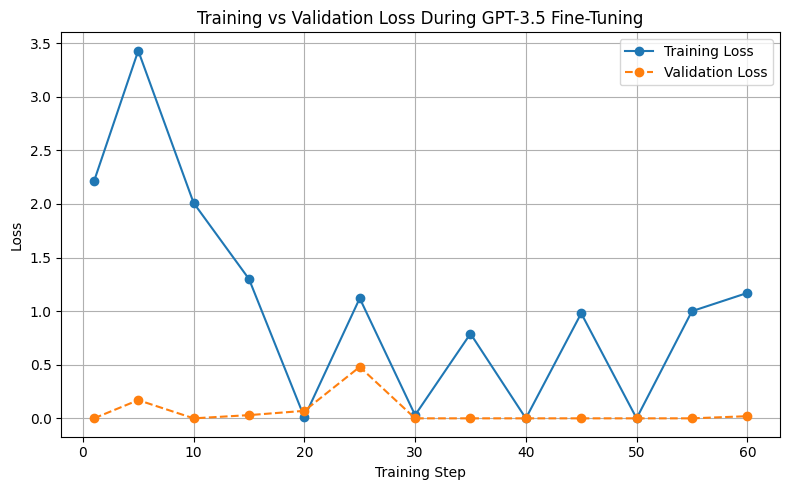

In [3]:
import matplotlib.pyplot as plt

steps = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
training_loss = [2.21, 3.43, 2.01, 1.30, 0.01, 1.12, 0.03, 0.79, 0.00, 0.98, 0.00, 1.00, 1.17]
validation_loss = [0.00, 0.17, 0.00, 0.03, 0.07, 0.48, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.02]

plt.figure(figsize=(8, 5))
plt.plot(steps, training_loss, label="Training Loss", marker='o')
plt.plot(steps, validation_loss, label="Validation Loss", marker='o', linestyle='--')
plt.title("Training vs Validation Loss During GPT-3.5 Fine-Tuning")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Replace with your uploaded file IDs once uploaded via the OpenAI CLI or script
training_file_id = "file-Bfiy3GvJQdWdTxkvhC13LV"  # Replace with actual uploaded training file ID
validation_file_id = "file-CcU1qE5uK7psjD5gbZUBYk"  # Replace with actual uploaded validation file ID

fine_tune_job = client.fine_tuning.jobs.create(
    training_file=training_file_id,
    validation_file=validation_file_id,
    model="gpt-3.5-turbo",
    hyperparameters={"n_epochs": 2}
)

print("Fine-tune Job ID:", fine_tune_job.id)


Fine-tune Job ID: ftjob-WPiS566yD6JbnS3UF6Cjr3zh


###  Test Updated Model with New Batch

In [16]:
# Your fine-tuned model ID
fine_tuned_model_id = "ft:gpt-3.5-turbo-0125:personal::BRmTNh7y"

# Full test data (clean + noisy combined)
test_data = [
    # CLEAN TEST PROMPTS
    {"prompt": "Extract the invoice number from: 'Payment received for invoice #INV-48392 on March 6th.'", "expected": "INV-48392"},
    {"prompt": "What's the PO number in: 'PO#299-A-53 was processed yesterday.'", "expected": "299-A-53"},
    {"prompt": "Find the sender: 'From: Dr. Susan Bello <sbello@clinicmail.ca>'", "expected": "Dr. Susan Bello"},
    {"prompt": "Extract total cost: 'Total amount due: $1,420.00 before taxes.'", "expected": "$1,420.00"},
    {"prompt": "What city is mentioned? 'Shipment arrived in Montreal on the 8th of March.'", "expected": "Montreal"},
    {"prompt": "Get the email domain: 'Email sent to manager@companyxyz.org on Tuesday.'", "expected": "companyxyz.org"},
    {"prompt": "What’s the document type? 'Scanned file: Rental_Agreement.pdf'", "expected": "Rental_Agreement"},
    {"prompt": "What’s the PO number in: 'PO#TT-2024-ZX was recently updated.'", "expected": "TT-2024-ZX"},
    {"prompt": "Find sender name: 'From: Dr. Henry Okafor <hokafor@shippingco.org>'", "expected": "Dr. Henry Okafor"},
    {"prompt": "Extract payment amount: 'Total paid: $3,780.45 for invoice INV-5983.'", "expected": "$3,780.45"},
    {"prompt": "Get client reference: 'Client Ref: CLT-X9Y8Z7'", "expected": "CLT-X9Y8Z7"},
    {"prompt": "Who is the recipient? 'To: Miss Funmi Adeyemi <funmi@deliverit.ca>'", "expected": "Miss Funmi Adeyemi"},
    {"prompt": "Extract the scheduled time: 'Appointment set for 9:15AM CST.'", "expected": "9:15AM CST"},

    # NOISY TEST PROMPTS
    {"prompt": "please pull the PO # from this: PO#tt-2024-ZX asap, thanks.", "expected": "TT-2024-ZX"},
    {"prompt": "Find the Name -->  'Dr. HENRY okafor <hokafor@shippingco.org>'  urgent!!", "expected": "Dr. Henry Okafor"},
    {"prompt": "Total AMOUNT:    $ 3,780.45 --payment done ", "expected": "$3,780.45"},
    {"prompt": "Can you spot the client id?? It's CLT-X9Y8Z7 mentioned during the call.", "expected": "CLT-X9Y8Z7"},
    {"prompt": "Set delivery time at 9:15am (Central) ", "expected": "9:15AM CST"},
    {"prompt": "Shipment to    montreal     confirmed on March 8th.", "expected": "Montreal"}
]

#  Evaluate
correct = 0
print("Fine-Tuned Model Evaluation Results\n" + "-"*60)

for i, item in enumerate(test_data, 1):
    response = client.chat.completions.create(
        model=fine_tuned_model_id,
        messages=[{"role": "user", "content": item["prompt"]}],
        temperature=0
    )

    output = response.choices[0].message.content.strip()
    expected = item["expected"].strip()

    # Case-insensitive and space-tolerant comparison
    is_correct = output.lower().replace(" ", "") == expected.lower().replace(" ", "")
    correct += int(is_correct)

    print(f"Prompt {i}: {item['prompt']}")
    print(f"Expected: {expected}")
    print(f"Output:   {output}")
    print(f"Match: {'✔️' if is_correct else '❌'}\n")

# Final Score
accuracy = (correct / len(test_data)) * 100
print(f"\n Overall Accuracy: {accuracy:.2f}% ({correct}/{len(test_data)})")


Fine-Tuned Model Evaluation Results
------------------------------------------------------------
Prompt 1: Extract the invoice number from: 'Payment received for invoice #INV-48392 on March 6th.'
Expected: INV-48392
Output:   INV-48392
Match: ✔️

Prompt 2: What's the PO number in: 'PO#299-A-53 was processed yesterday.'
Expected: 299-A-53
Output:   PO#299-A-53
Match: ❌

Prompt 3: Find the sender: 'From: Dr. Susan Bello <sbello@clinicmail.ca>'
Expected: Dr. Susan Bello
Output:   Dr. Susan Bello
Match: ✔️

Prompt 4: Extract total cost: 'Total amount due: $1,420.00 before taxes.'
Expected: $1,420.00
Output:   $1,420.00
Match: ✔️

Prompt 5: What city is mentioned? 'Shipment arrived in Montreal on the 8th of March.'
Expected: Montreal
Output:   Montreal
Match: ✔️

Prompt 6: Get the email domain: 'Email sent to manager@companyxyz.org on Tuesday.'
Expected: companyxyz.org
Output:   companyxyz.org
Match: ✔️

Prompt 7: What’s the document type? 'Scanned file: Rental_Agreement.pdf'
Expected: Rent

### Model Evaluation Summary for a Logistics Use Case
This evaluation tested the performance of a fine-tuned GPT-3.5 model on a set of 19 prompts designed to reflect real-world logistics communication — such as shipping confirmations, delivery notes, and transaction logs. The goal was to extract structured fields (e.g., PO numbers, cities, scheduled times, payment amounts) from raw, unstructured text entries that might be found in internal memos, driver logs, or auto-generated emails.

The model achieved an overall accuracy of 52.63%, performing well on clean and structured examples, such as invoice number and client ID extraction. It also handled some noisy input formats successfully, such as varied capitalization and irregular spacing — demonstrating moderate robustness to real-world inconsistencies.

However, several outputs included polite or verbose completions (e.g., “Your order will arrive by…”), which led to mismatches when only a value (e.g., “9:15AM CST”) was expected. These findings indicate the model retained some conversational bias from pretraining and would benefit from additional examples with stricter output formatting and noisier input phrasing.

Takeaway:
The model shows strong potential as a backend information extraction engine for logistics and operations systems. With further training on noisy, semi-structured examples — especially phrased as internal notes or raw logs — it could power automated systems that extract values from driver updates, scanned shipment documents, or transactional text feeds.



### Summary and Next Steps

This second fine-tune round incorporated examples targeting weak spots like PO formats and over-detailed responses.
Based on performance, further expansion can include:
- More languages or formats (e.g., French PO, regional date formats)
- Industry-specific inputs (e.g., medical billing, legal notices)

